# STEP-1 : IMPORTING LIBRARIES

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# STEP-2 : UPLOAD THE DATASET

In [3]:
df = pd.read_csv("messy_sales.csv")
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,January 15 2024,north,tablet,electronics,32,USD 858,########,10%
1,1/30/2024,north,Tablet,Electronics,72,$833.83,########,15 percent
2,2/13/2024,EAST,laptop,ELEC,NaN,489.12,NaN,0.08
3,4/28/2024,West,Laptop,gadget,thirty,$733.46,########,0.1
4,2/18/2024,EAST,Phone,ELEC,47,USD 373,"40,920",0.1


# STEP-3 : CHECK FOR MISSING VALUES 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Date               200 non-null    str  
 1   Region             200 non-null    str  
 2   Product            200 non-null    str  
 3   Category           200 non-null    str  
 4   Units Sold         196 non-null    str  
 5   Unit Price         200 non-null    str  
 6   Total Sales        197 non-null    str  
 7   Profit Margin (%)  200 non-null    str  
dtypes: str(8)
memory usage: 12.6 KB


In [5]:
df.dtypes

Date                 str
Region               str
Product              str
Category             str
Units Sold           str
Unit Price           str
Total Sales          str
Profit Margin (%)    str
dtype: object

In [6]:
df.isnull().sum()

Date                 0
Region               0
Product              0
Category             0
Units Sold           4
Unit Price           0
Total Sales          3
Profit Margin (%)    0
dtype: int64

In [7]:
df["Units Sold"] = pd.to_numeric(df["Units Sold"], errors='coerce')
df["Total Sales"] = pd.to_numeric(df["Total Sales"], errors='coerce')

In [8]:
df["Units Sold"] = df["Units Sold"].fillna(df["Units Sold"].mean())
df["Total Sales"] = df["Total Sales"].fillna(df["Total Sales"].mean())

In [9]:
df.isnull().sum()

Date                 0
Region               0
Product              0
Category             0
Units Sold           0
Unit Price           0
Total Sales          0
Profit Margin (%)    0
dtype: int64

# STEP-4 : CLEAN COLUMNS NAME

In [10]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['date', 'region', 'product', 'category', 'units sold', 'unit price',
       'total sales', 'profit margin (%)'],
      dtype='str')

# STEP-5 : FIX DATE FORMATE

In [11]:
df["date"] = pd.to_datetime(df["date"], errors = "coerce")
df["date"].dtype

dtype('<M8[us]')

# STEP-6 : STANDARDIZE TEXT COLUMNS

In [12]:
for col in ["region", "product", "category"] :
    df[col] = df[col].str.strip().str.title()

# STEP-7 : CLEAN CURRENCY COLUMNS (UNITS PRICE & TOTAL SALES)

In [13]:
for col in ["unit price", "total sales"] :
    df[col] = df[col].astype(str)
    df[col] = (
        df[col].str.replace("[$,USD ]","", regex = True).str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors = "coerce")

In [14]:
df.head()

,date,region,product,category,units sold,unit price,total sales,profit margin (%)
0,2024-01-15,North,Tablet,Electronics,32.000000,858.00,26096.323077,10%
1,NaT,North,Tablet,Electronics,72.000000,833.83,26096.323077,15 percent
2,NaT,East,Laptop,Elec,52.307692,489.12,26096.323077,0.08
3,NaT,West,Laptop,Gadget,52.307692,733.46,26096.323077,0.1
4,NaT,East,Phone,Elec,47.000000,373.00,26096.323077,0.1


# STEP-8 : SOLVE PROFIT MARGIN (%)

In [15]:
df["profit margin (%)"] = (
    df["profit margin (%)"].astype(str).str.replace("%", "", regex = True).str.replace("percent", "", regex = True).astype(float)
)
df["profit margin (%)"] = np.where(df["profit margin (%)"] < 1, df["profit margin (%)"]*100, df["profit margin (%)"])

In [16]:
df.head()

,date,region,product,category,units sold,unit price,total sales,profit margin (%)
0,2024-01-15,North,Tablet,Electronics,32.000000,858.00,26096.323077,10.0
1,NaT,North,Tablet,Electronics,72.000000,833.83,26096.323077,15.0
2,NaT,East,Laptop,Elec,52.307692,489.12,26096.323077,8.0
3,NaT,West,Laptop,Gadget,52.307692,733.46,26096.323077,10.0
4,NaT,East,Phone,Elec,47.000000,373.00,26096.323077,10.0


# STEP-9 : DELETE ROWS WITH MISSING DATA

In [17]:
df_cleaned = df.dropna(subset = ["date", "total sales", "region"])

In [18]:
df_cleaned.isna().sum()

date                 0
region               0
product              0
category             0
units sold           0
unit price           0
total sales          0
profit margin (%)    0
dtype: int64

# STEP-10 : TOTAL SALES BY REGION

C:\Users\dell\AppData\Local\Temp\ipykernel_18408\3489321977.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_cleaned, x = "region", y = "total sales", estimator=sum, palette= "cool")


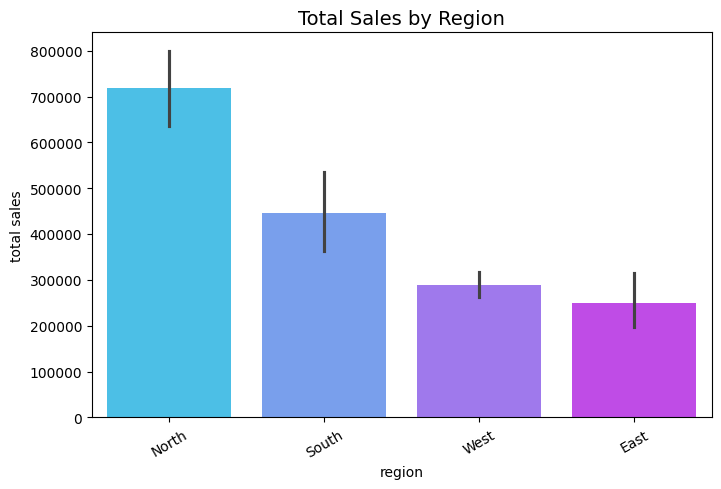

In [20]:
plt.figure(figsize = (8,5))
sns.barplot(data = df_cleaned, x = "region", y = "total sales", estimator=sum, palette= "cool")
plt.title("Total Sales by Region", fontsize = 14)
plt.xticks(rotation = 30)
plt.show()

# STEP 11: SALES TREND OVER TIME

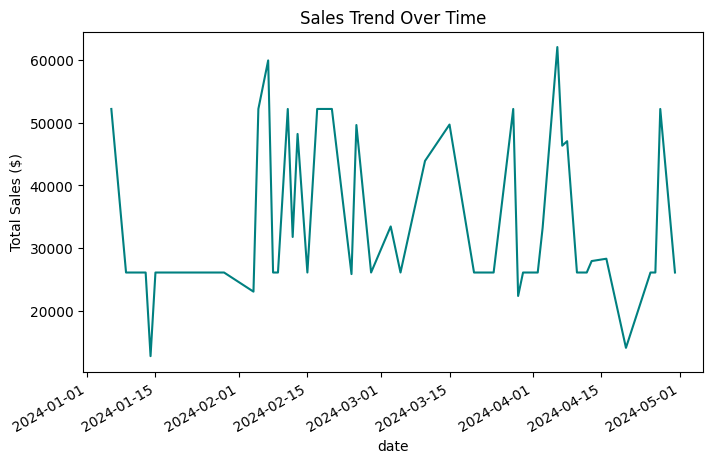

In [21]:
plt.figure(figsize = (8,5))
df_cleaned.groupby("date")["total sales"].sum().plot(kind = "line", color = "teal")
plt.title("Sales Trend Over Time")
plt.ylabel("Total Sales ($)")
plt.show()

# STEP 12: CATEGORY SHARE PIE CHART

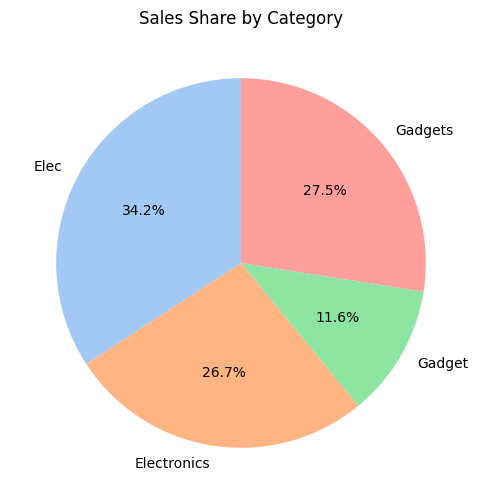

In [22]:
plt.figure(figsize = (6,6))
category_sales = df_cleaned.groupby("category")["total sales"].sum()
category_sales.plot(kind = "pie", autopct = "%1.1f%%", startangle = 90, colors = sns.color_palette("pastel"))
plt.title("Sales Share by Category")
plt.ylabel("")
plt.show()